 Install & Import


In [14]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Done")

Done


Upload & Load Dataset

In [15]:
df = pd.read_csv('city_day.csv')
print(df.shape)
df.head()

(29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


EDA

Shape: (29531, 16)

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

AQI Stats:
 count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


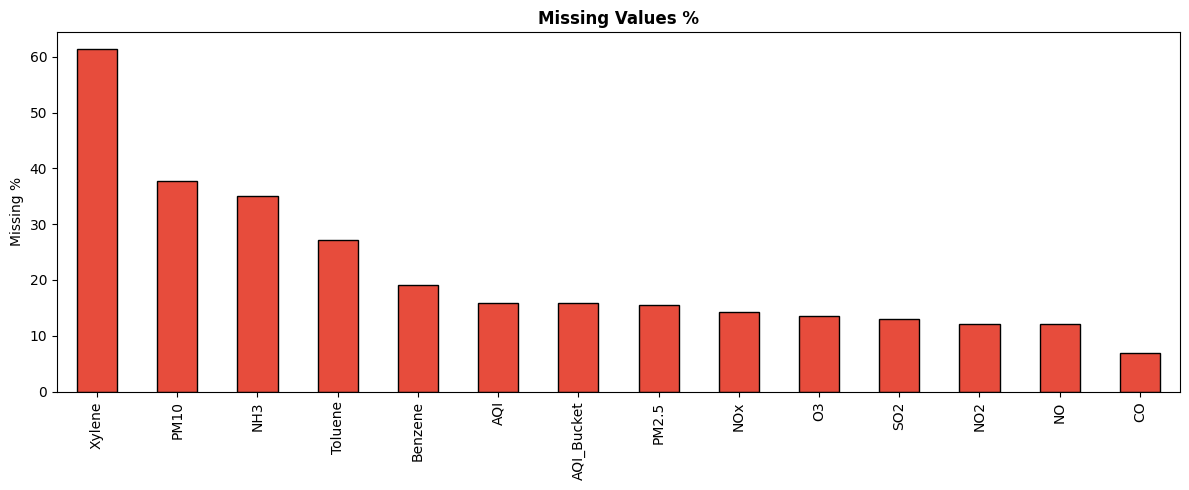

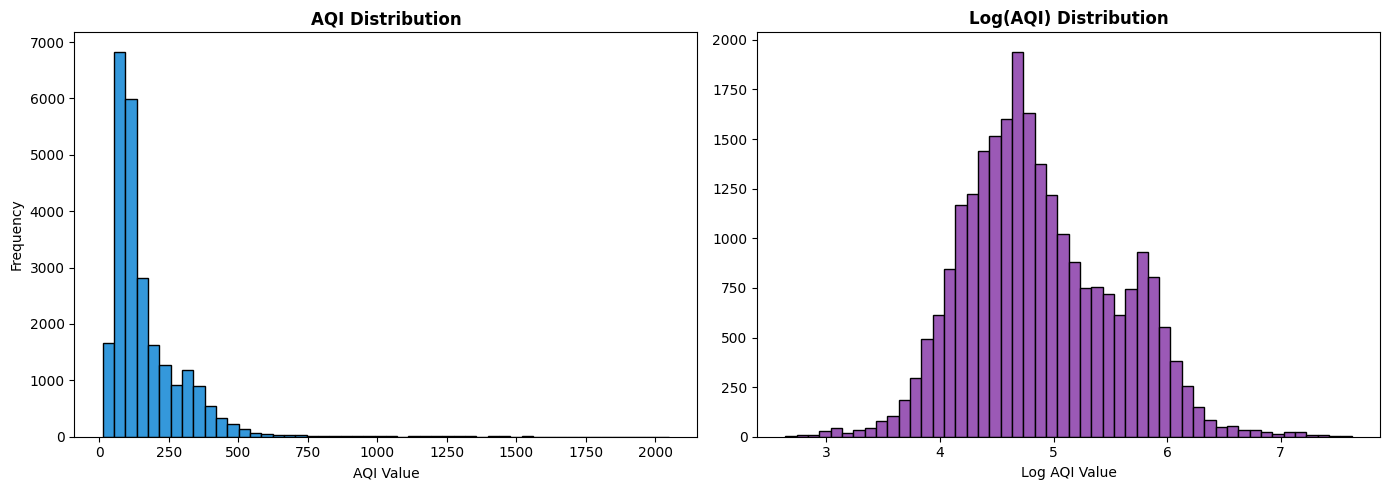

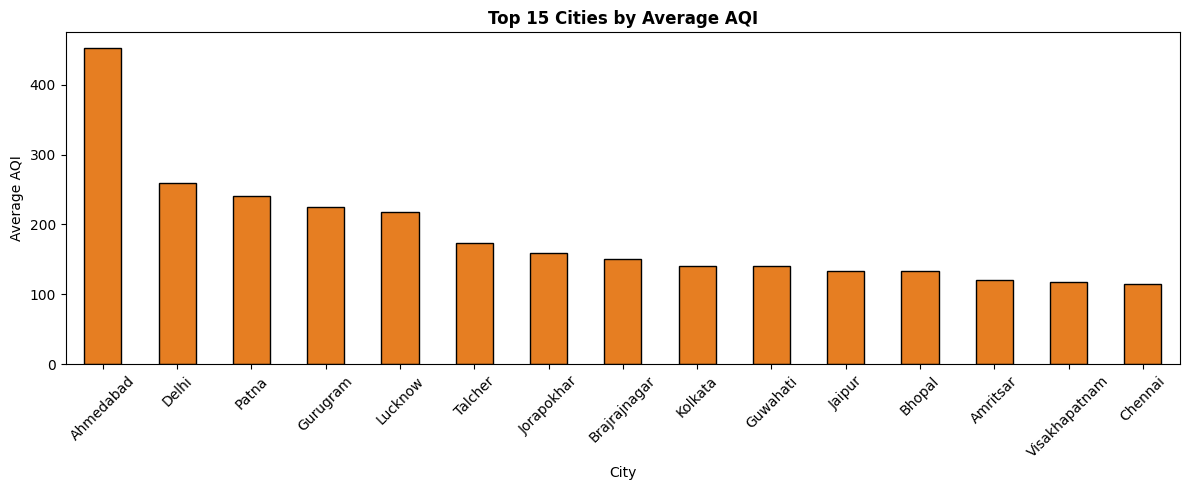

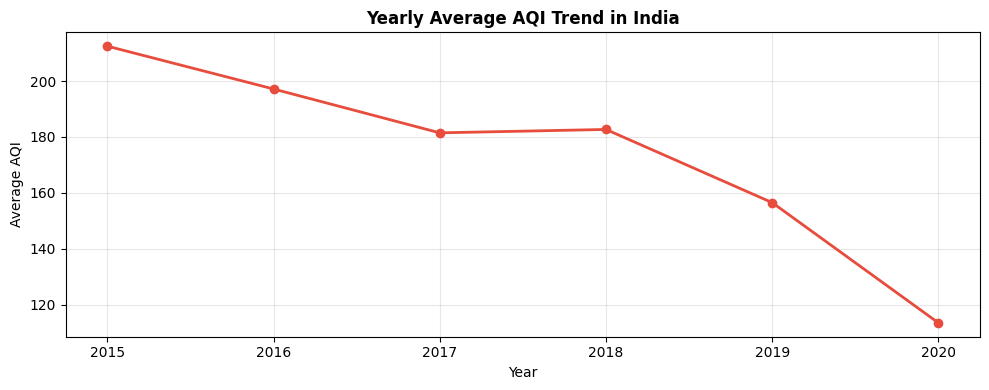

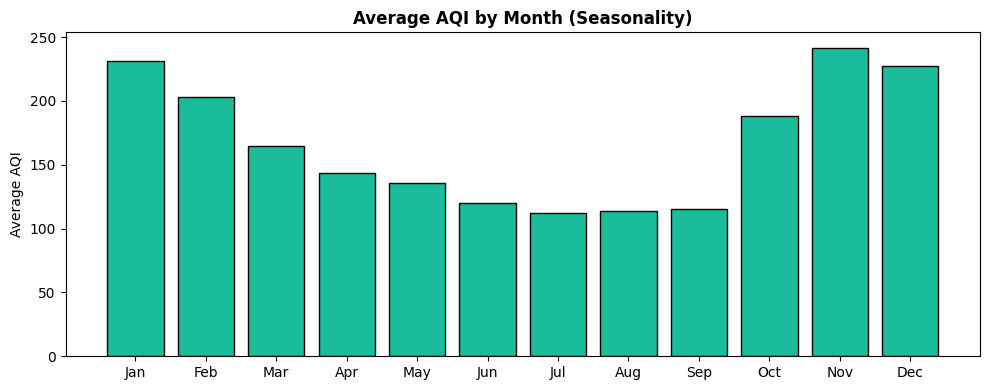

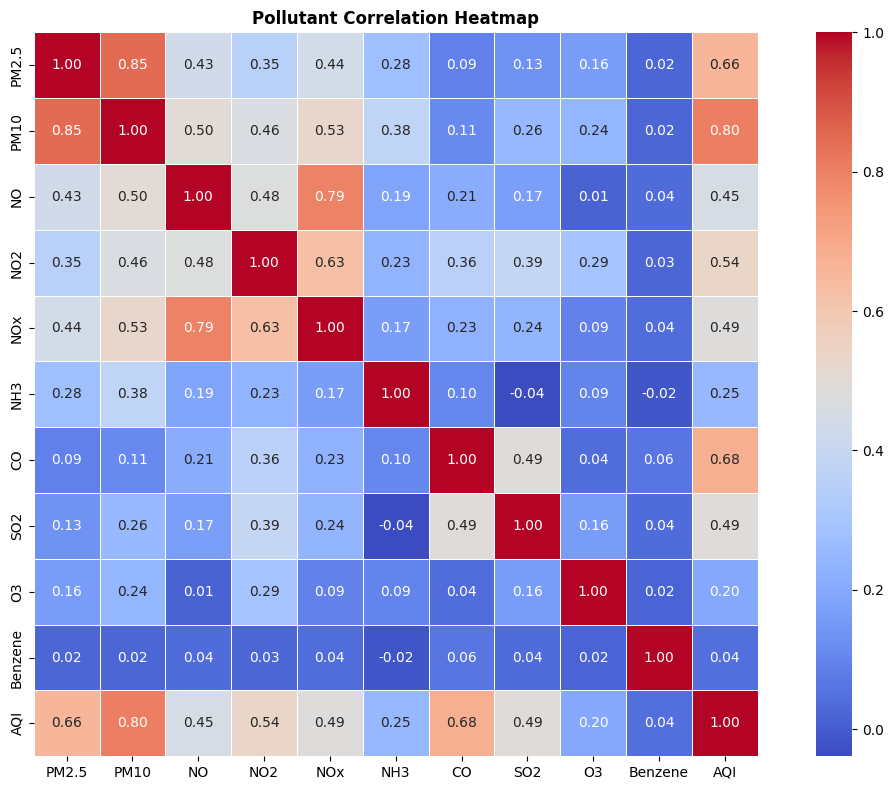

In [16]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nAQI Stats:\n", df['AQI'].describe())

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 5))
missing[missing > 0].plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Missing Values %', fontweight='bold')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AQI'].dropna(), bins=50, color='#3498db', edgecolor='black')
axes[0].set_title('AQI Distribution', fontweight='bold')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['AQI'].dropna()), bins=50, color='#9b59b6', edgecolor='black')
axes[1].set_title('Log(AQI) Distribution', fontweight='bold')
axes[1].set_xlabel('Log AQI Value')

plt.tight_layout()
plt.show()

top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 5))
top_cities.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Top 15 Cities by Average AQI', fontweight='bold')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

yearly_aqi = df.groupby('Year')['AQI'].mean()
plt.figure(figsize=(10, 4))
yearly_aqi.plot(kind='line', marker='o', color='#e74c3c', linewidth=2)
plt.title('Yearly Average AQI Trend in India', fontweight='bold')
plt.ylabel('Average AQI')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

monthly_aqi = df.groupby('Month')['AQI'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 4))
plt.bar(months, monthly_aqi.values, color='#1abc9c', edgecolor='black')
plt.title('Average AQI by Month (Seasonality)', fontweight='bold')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.show()

pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','AQI']
corr_df = df[pollutants].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Pollutant Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

Cleaning & Preprocessing

In [17]:
df = df.dropna(subset=['AQI'])
print("After dropping null AQI rows:", df.shape)

features = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Year','Month','City']
df_model = df[features + ['AQI']].copy()

pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
for col in pollutant_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

le = LabelEncoder()
df_model['City_enc'] = le.fit_transform(df_model['City'])
df_model.drop('City', axis=1, inplace=True)

print("Preprocessing done")
print(df_model.isnull().sum().sum(), "nulls remaining")
df_model.head()

After dropping null AQI rows: (24850, 18)
Preprocessing done
0 nulls remaining


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Year,Month,AQI,City_enc
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,2015,1,209.0,0
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,2015,1,328.0,0
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,2015,1,514.0,0
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,2015,2,782.0,0
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,2015,2,914.0,0


Feature Engineering

In [18]:
df_model['AQI_log'] = np.log1p(df_model['AQI'])

X = df_model.drop(['AQI', 'AQI_log'], axis=1)
y = df_model['AQI_log']   # predicting log AQI

print("Features used:", X.columns.tolist())
print("X shape:", X.shape)

Features used: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Year', 'Month', 'City_enc']
X shape: (24850, 14)


Train/Test Split & Scaling

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (19880, 14)
Test : (4970, 14)


Train Multiple Models

In [20]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Lasso Regression'    : Lasso(alpha=0.01),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'             : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_sc, y_train)
        y_pred_log = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae  = mean_absolute_error(y_actual, y_pred)
    r2   = r2_score(y_actual, y_pred)

    results[name] = {'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R² Score': round(r2,4)}

    print(f"\n{'='*40}")
    print(f"🔹 {name}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"MAE     : {mae:.2f}")
    print(f"R² Score: {r2:.4f}")


🔹 Linear Regression
RMSE    : 507.74
MAE     : 68.10
R² Score: -13.0788

🔹 Ridge Regression
RMSE    : 507.63
MAE     : 68.09
R² Score: -13.0729

🔹 Lasso Regression
RMSE    : 484.89
MAE     : 66.70
R² Score: -11.8403

🔹 Random Forest
RMSE    : 41.63
MAE     : 20.42
R² Score: 0.9054

🔹 Gradient Boosting
RMSE    : 48.56
MAE     : 23.63
R² Score: 0.8712

🔹 XGBoost
RMSE    : 43.29
MAE     : 21.04
R² Score: 0.8977


Evaluation & Visualizations


=== Model Comparison ===
                     RMSE    MAE  R² Score
Random Forest       41.63  20.42    0.9054
XGBoost             43.29  21.04    0.8977
Gradient Boosting   48.56  23.63    0.8712
Lasso Regression   484.89  66.70  -11.8403
Ridge Regression   507.63  68.09  -13.0729
Linear Regression  507.74  68.10  -13.0788


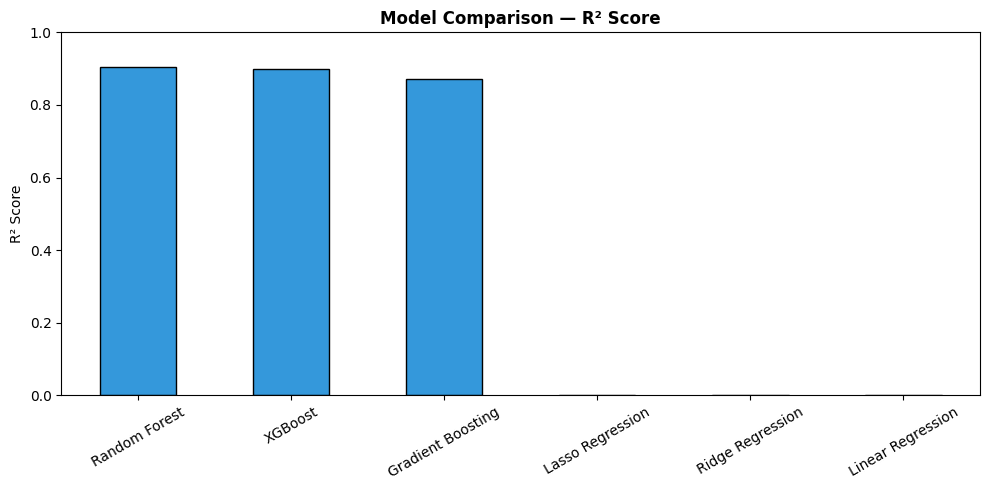

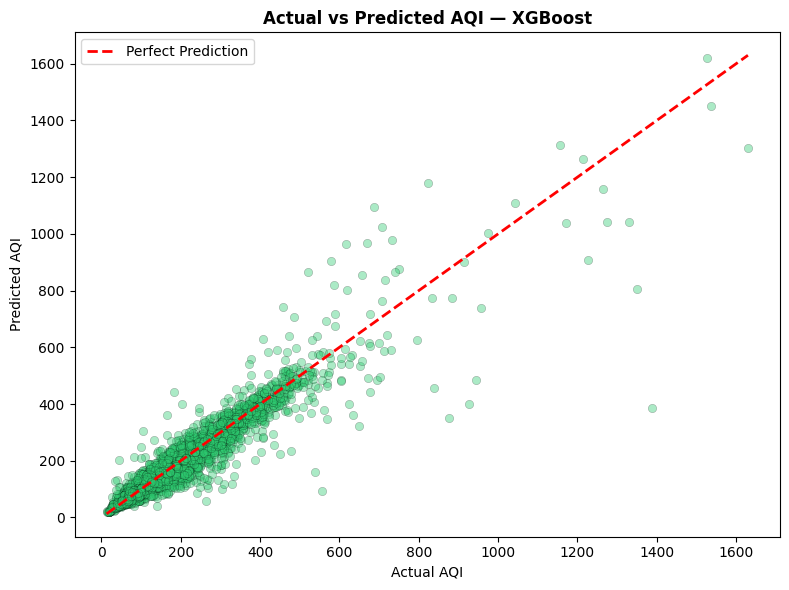

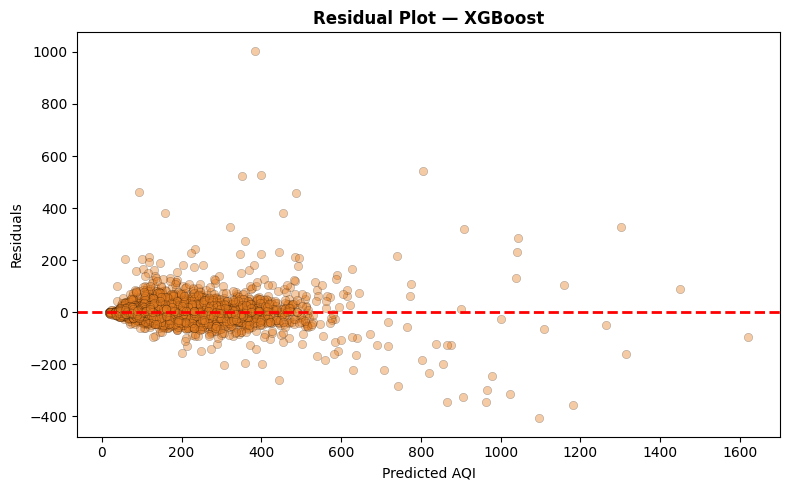

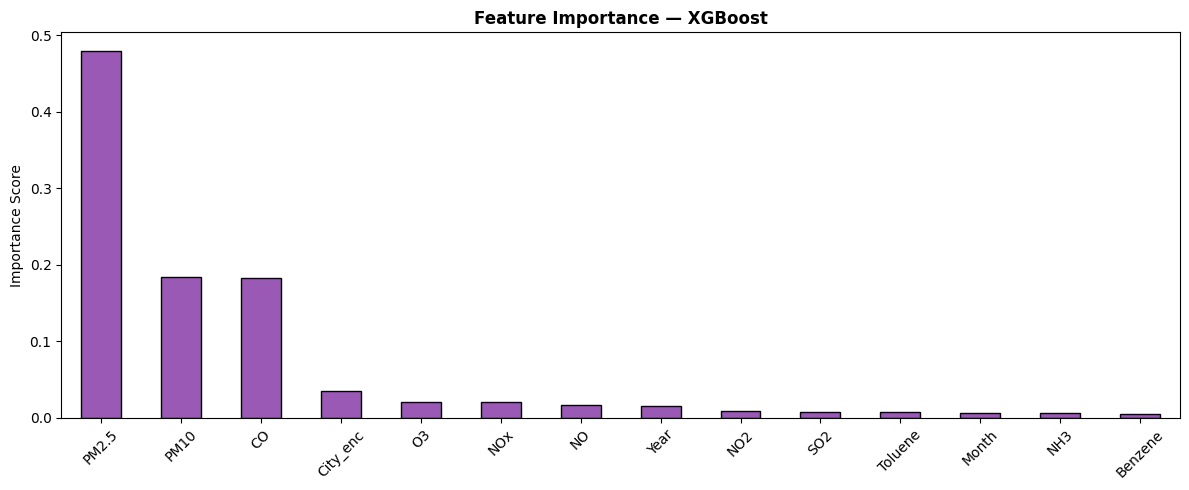

In [21]:
results_df = pd.DataFrame(results).T.sort_values('R² Score', ascending=False)
print("\n=== Model Comparison ===")
print(results_df)

results_df['R² Score'].plot(kind='bar', color='#3498db', edgecolor='black', figsize=(10,5))
plt.title('Model Comparison — R² Score', fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

best_model = models['XGBoost']
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.4, color='#2ecc71', edgecolors='black', linewidths=0.3)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI — XGBoost', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_actual.values - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='#e67e22', edgecolors='black', linewidths=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.title('Residual Plot — XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

feat_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).plot(
    kind='bar', color='#9b59b6', edgecolor='black', figsize=(12,5))
plt.title('Feature Importance — XGBoost', fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Predict AQI for Any City

In [22]:
def predict_aqi(city, pm25, pm10, no2, co, so2, o3, year=2024, month=6):
    city_enc = le.transform([city])[0]
    input_data = pd.DataFrame([[pm25, pm10, 0, no2, 0, 0, co, so2, o3,
                                  0, 0, year, month, city_enc]],
                               columns=X.columns)
    pred_log = best_model.predict(input_data)[0]
    aqi = np.expm1(pred_log)

    if aqi <= 50:    category = "🟢 Good"
    elif aqi <= 100: category = "🟡 Satisfactory"
    elif aqi <= 200: category = "🟠 Moderate"
    elif aqi <= 300: category = "🔴 Poor"
    elif aqi <= 400: category = "🟣 Very Poor"
    else:            category = "⚫ Severe"

    print(f"City     : {city}")
    print(f"Predicted AQI : {aqi:.1f}")
    print(f"Category : {category}")
